# 02 · Comprensión de los datos

**Fase 2 de CRISP-DM**

Análisis exploratorio del dataset de productos para comprender la estructura, calidad y distribución de las variables clave.

In [ ]:
import os
from pathlib import Path

# Garantiza que el CWD sea la raíz del repositorio
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

from seller_segmentation.data.loader import load_df

sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline

## 1. Carga de datos

In [2]:
df = load_df()
print(f"Dimensiones: {df.shape}")
df.head(3)

Dimensiones: (185250, 14)


,tim_day,seller_nickname,titulo,seller_reputation,stock,logistic_type,condition,is_refurbished,price,regular_price,categoria,url,category_id,category_name
0,2024-08-01,4fe042a785,Consoladores Vibradores Vibrador Bucal Con Fla...,NaN,1,DS,new,False,9999999.00,NaN,EROTIC,https://articulo.mercadolibre.com.mx/MLM-32027...,EROTIC,PRODUCTOS ERÓTICOS
1,2024-08-01,40017eb54f,Aire Acondicionado Mabe Mini Split Inverter ...,green_gold,1,XD,new,False,999999.99,NaN,HOUSEHOLD APPLIANCES,https://articulo.mercadolibre.com.mx/MLM-15243...,HOUSEHOLD APPLIANCES,ELECTRODOMÉSTICOS
2,2024-08-01,40017eb54f,Aire Acondicionado Mabe Mini Split Inverter ...,green_gold,0,XD,new,False,999999.99,NaN,HOUSEHOLD APPLIANCES,https://articulo.mercadolibre.com.mx/MLM-15243...,HOUSEHOLD APPLIANCES,ELECTRODOMÉSTICOS


In [3]:
print('Volumetria_Total:',df.shape)
print('Volumetria_sin_duplicados:',df.drop_duplicates().shape)

Volumetria_Total: (185250, 14)
Volumetria_sin_duplicados: (185250, 14)


In [4]:
df[df['seller_nickname']=='907ab8ff30'].head(5)

,tim_day,seller_nickname,titulo,seller_reputation,stock,logistic_type,condition,is_refurbished,price,regular_price,categoria,url,category_id,category_name
89,2024-08-01,907ab8ff30,Smart Tv Samsung Un55cu7000gczb Led 4k 55 220v,green_gold,1,XD,new,False,9999.00,NaN,TELEVISIONS & STREAMING DEVICES,https://articulo.mercadolibre.com.mx/MLM-27766...,TELEVISIONS & STREAMING DEVICES,TELEVISORES Y DISPOSITIVOS DE STREAMING
90,2024-08-01,907ab8ff30,Smart Tv Samsung Un55cu7000gczb Led 4k 55 220v,green_gold,1,XD,new,False,9999.00,NaN,TELEVISIONS & STREAMING DEVICES,https://articulo.mercadolibre.com.mx/MLM-27765...,TELEVISIONS & STREAMING DEVICES,TELEVISORES Y DISPOSITIVOS DE STREAMING
3210,2024-08-01,907ab8ff30,Base Soporte Tv Brazo Reforzado 30-75p 50kg Ve...,green_gold,13,FBM,new,False,988.00,NaN,TELEVISIONS & STREAMING DEVICES,https://articulo.mercadolibre.com.mx/MLM-26651...,TELEVISIONS & STREAMING DEVICES,TELEVISORES Y DISPOSITIVOS DE STREAMING
56494,2024-08-01,907ab8ff30,Soporte Pantalla Tv Fijo Inclinac 32 A 75 Pul ...,green_gold,8,FBM,new,False,500.65,527.0,TELEVISIONS & STREAMING DEVICES,https://articulo.mercadolibre.com.mx/MLM-16886...,TELEVISIONS & STREAMING DEVICES,TELEVISORES Y DISPOSITIVOS DE STREAMING
89777,2024-08-01,907ab8ff30,Base Pantalla Tv Inclinacion 32 43 49 55 Pul V...,green_gold,60,FBM,new,False,339.00,NaN,TELEVISIONS & STREAMING DEVICES,https://articulo.mercadolibre.com.mx/MLM-13137...,TELEVISIONS & STREAMING DEVICES,TELEVISORES Y DISPOSITIVOS DE STREAMING


## 2. Esquema y tipos de datos

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185250 entries, 0 to 185249
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   tim_day            185250 non-null  str    
 1   seller_nickname    185250 non-null  str    
 2   titulo             185250 non-null  str    
 3   seller_reputation  182878 non-null  str    
 4   stock              185250 non-null  int64  
 5   logistic_type      185250 non-null  str    
 6   condition          185250 non-null  str    
 7   is_refurbished     185250 non-null  bool   
 8   price              183734 non-null  float64
 9   regular_price      49956 non-null   float64
 10  categoria          185250 non-null  str    
 11  url                185250 non-null  str    
 12  category_id        185250 non-null  str    
 13  category_name      185250 non-null  str    
dtypes: bool(1), float64(2), int64(1), str(10)
memory usage: 18.6 MB


In [6]:
df.columns

Index(['tim_day', 'seller_nickname', 'titulo', 'seller_reputation', 'stock',
       'logistic_type', 'condition', 'is_refurbished', 'price',
       'regular_price', 'categoria', 'url', 'category_id', 'category_name'],
      dtype='str')

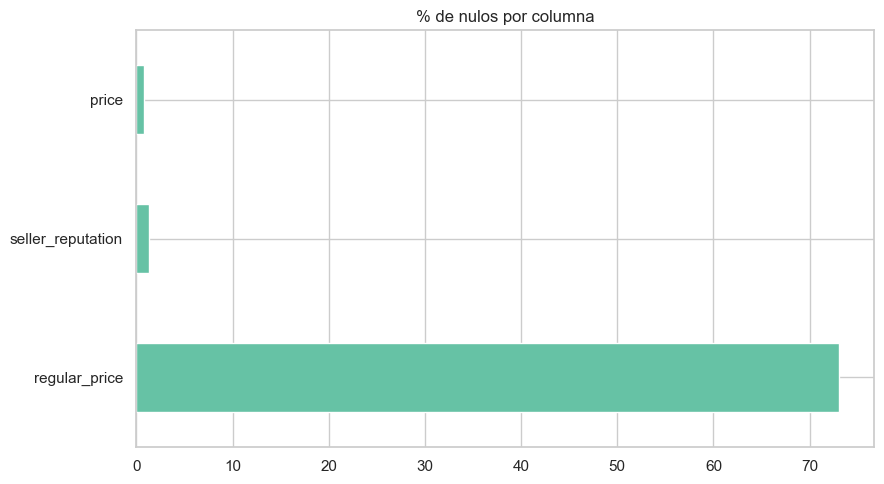

In [7]:
# Porcentaje de nulos por columna
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct[null_pct > 0].plot(kind="barh", figsize=(9, 5), title="% de nulos por columna")
plt.tight_layout()

## 3. Entendimiento de las variables 

Se inicia revisando las categorías y distribuciones de las variables categoricas, para continuar analizando las númericas y sus estadísticas.

In [8]:
seller_nickname = df.groupby('seller_nickname').size().sort_values(ascending=False)
seller_nickname

seller_nickname
a9847ce81d    1421
5a39342818     877
77b179c68c     876
d5f5bc5f45     795
02cdf9f94d     510
              ... 
703a4c4b5b       1
7037c902fa       1
703451d0ac       1
7030d72c1a       1
ffff407100       1
Length: 46586, dtype: int64

In [9]:
seller_reputation = df.groupby('seller_reputation').size().sort_values(ascending=False)
seller_reputation


seller_reputation
green_platinum    69625
green             33838
green_gold        28332
green_silver      24731
newbie             9221
yellow             7245
red                4219
light_green        3101
orange             2566
dtype: int64

In [10]:
logistic_type = df.groupby('logistic_type').size().sort_values(ascending=False)
logistic_type

logistic_type
XD      116763
FBM      31483
DS       24645
Otro     10541
FLEX      1818
dtype: int64

In [11]:
condition = df.groupby('condition').size().sort_values(ascending=False)
condition

condition
new              169616
used              15551
not_specified        83
dtype: int64

In [12]:
is_refurbished = df.groupby('is_refurbished').size().sort_values(ascending=False)
is_refurbished

is_refurbished
False    184515
True        735
dtype: int64

In [13]:
categoria = df.groupby('categoria').size().sort_values(ascending=False)
print(categoria.shape)
categoria

(54,)


categoria
SPORTS                                 14252
HEALTH                                 12587
BOOKS, MULTIMEDIA & OTHER E!           10355
TOYS AND GAMES                         10251
ACC CARS & VANS                        10128
OTHER                                   7797
HOUSEHOLD APPLIANCES                    7090
ANTIQUES & HOBBIES                      6453
HOUSEHOLD ITEMS                         5569
APPAREL ACCESSORIES                     5423
AUDIO & GENERAL ELECTRONICS             5373
APPAREL                                 5356
FRAGRANCES & MAKE UP                    5203
SMARTPHONES & TABLETS                   5197
PET                                     4926
TOOLS                                   4535
IT PERIPHERALS, PARTS & ACCESSORIES     4150
BEAUTY PERSONAL CARE                    4129
FOODS                                   3923
MUSICAL INSTRUMENTS                     3895
FOOTWEAR                                3473
PARTY                                   2881


In [14]:
category_id = df.groupby('category_id').size().sort_values(ascending=False)
print(category_id.shape)
category_id

(54,)


category_id
SPORTS                                 14252
HEALTH                                 12587
BOOKS, MULTIMEDIA & OTHER E!           10355
TOYS AND GAMES                         10251
ACC CARS & VANS                        10128
OTHER                                   7797
HOUSEHOLD APPLIANCES                    7090
ANTIQUES & HOBBIES                      6453
HOUSEHOLD ITEMS                         5569
APPAREL ACCESSORIES                     5423
AUDIO & GENERAL ELECTRONICS             5373
APPAREL                                 5356
FRAGRANCES & MAKE UP                    5203
SMARTPHONES & TABLETS                   5197
PET                                     4926
TOOLS                                   4535
IT PERIPHERALS, PARTS & ACCESSORIES     4150
BEAUTY PERSONAL CARE                    4129
FOODS                                   3923
MUSICAL INSTRUMENTS                     3895
FOOTWEAR                                3473
PARTY                                   288

In [15]:
category_name = df.groupby('category_name').size().sort_values(ascending=False)
print(category_name.shape)
category_name

(54,)


category_name
DEPORTES                                   14252
SALUD                                      12587
LIBROS, MULTIMEDIA Y OTROS                 10355
JUGUETES Y JUEGOS                          10251
ACCESORIOS PARA AUTOS Y CAMIONETAS         10128
OTROS                                       7797
ELECTRODOMÉSTICOS                           7090
ANTIGÜEDADES Y PASATIEMPOS                  6453
ARTÍCULOS DEL HOGAR                         5569
ACCESORIOS DE VESTIR                        5423
AUDIO Y ELECTRÓNICA GENERAL                 5373
ROPA                                        5356
FRAGANCIAS Y MAQUILLAJE                     5203
TELÉFONOS INTELIGENTES Y TABLETAS           5197
MASCOTAS                                    4926
HERRAMIENTAS                                4535
PERIFÉRICOS Y ACCESORIOS DE INFORMÁTICA     4150
CUIDADO PERSONAL Y BELLEZA                  4129
ALIMENTOS                                   3923
INSTRUMENTOS MUSICALES                      3895
CALZAD

In [16]:
# Comparar variables categoria, category_id, category_name
mapeo = df[['categoria', 'category_id', 'category_name']].drop_duplicates().sort_values('categoria')
print()
print(f'Combinaciones únicas: {len(mapeo)}')
print()
print(mapeo.to_string(index=False))


Combinaciones únicas: 54

                          categoria                         category_id                           category_name
      ACC AGRO VEHICLES & EQUIPMENT       ACC AGRO VEHICLES & EQUIPMENT            ACCESORIOS Y EQUIPO AGRÍCOLA
                    ACC CARS & VANS                     ACC CARS & VANS      ACCESORIOS PARA AUTOS Y CAMIONETAS
            ACC COMMERCIAL VEHICLES             ACC COMMERCIAL VEHICLES   ACCESORIOS PARA VEHÍCULOS COMERCIALES
                    ACC MOTORCYCLES                     ACC MOTORCYCLES            ACCESORIOS PARA MOTOCICLETAS
              ACC NAUTICAL VEHICLES               ACC NAUTICAL VEHICLES                     ACCESORIOS NÁUTICOS
                          ACC TIRES                           ACC TIRES                    LLANTAS Y ACCESORIOS
                          ACC TOOLS                           ACC TOOLS             HERRAMIENTAS PARA VEHÍCULOS
           ACC VEHICULAR MULTIMEDIA            ACC VEHICULAR MULTIMEDIA      

In [17]:
tim_day = df.groupby('tim_day').size().sort_values(ascending=False)
tim_day

tim_day
2024-08-01    185250
dtype: int64

Supuesto: De acuerdo a revisión en línea de posibles interpretaciones de las diferentes variables del caso de negocio, se definen las siguientes y se toman las siguientes acciones.

**Conclusión variables categóricas:**
  
- *tim_day*: Variable Fecha

- *seller_nickname*: Código que identifica al vendedor en la plataforma.

- *titulo*: Título de la publicación. Texto ingresado por el vendedor para describir el producto. Tiene un límite de caracteres y MercadoLibre aplica reglas de moderación.

- *seller_reputation*: Nivel de reputación del vendedor, calculado en base a ventas, cancelaciones, reclamos y calificaciones negativas. Variable ordinal.

| Categoría | Cantidad | Nivel | Orden |
|-----------|----------|-------|-------|
| green_platinum | 69625 | Platinum | 1-mejor |
| green_gold | 28332 | Oro | 2 |
| green_silver | 24731 | Plata | 3 |
| green | 33838 | Verde | 4 |
| light_green | 3101 | Verde Claro | 5 |
| yellow | 7245 | Amarillo | 6 |
| orange | 2566 | Naranja | 7 |
| red | 4219 | Rojo | 8-activo pero bajo |
| newbie | 9221 | Nuevo | Sin historial suficiente |

<br>

- *logistic_type*: Modalidad de la logística con la que se despacha el producto.

| Categoría | Cantidad | Descriptiva |
|-----------|----------|-------------|
| XD | 116763 | Cross Docking: El vendedor lleva el paquete a un punto de despacho autorizado (OCA, correo, punto ML). ML toma el paquete desde ahí y gestiona el último tramo hasta el comprador. |
| FBM | 31483 | Fulfillment by Merchant: El vendedor gestiona el envío de extremo a extremo, fuera de la red logística de ML. |
| DS | 24645 | Drop Shipping: El vendedor despacha directamente desde un proveedor o depósito propio hacia el comprador, sin intermediar físicamente el producto. Común en vendors que venden sin stock propio. |
| Otro | 10541 | Mercado Envíos Flex: El vendedor realiza la entrega por sus propios medios el mismo día o día siguiente, dentro de su zona. ML certifica al vendedor para operar en este modo. |
| FLEX | 1818 | Sin clasificación: Publicaciones sin modalidad logística definida, o modos legacy no mapeados. |

<br>

- *condition*: Estado del producto publicado:

| Categoría | Cantidad | Descriptiva |
|-----------|----------|-------------|
| new | 169616 | Nuevo |
| used | 15551 | Usado |
| not_specified | 83 | No especificado |

<br>

- *is_refurbished*: Booleano (true / false). Indica si el producto es reacondicionado certificado. Aplica principalmente a electrónica (celulares, notebooks).

| Categoría | Cantidad | Descriptiva |
|-----------|----------|-------------|
| False | 184515 | Artículo no reacondicionado certificado |
| True | 735 | Producto reacondicionado certificado |

<br>

- *categoria, category_id, category_name*: Nombre de la categoría a la que pertenece la publicación.

| Variable | Tipo | Descripción |
|---------|------|-------------|
| categoria | string | Categoría en inglés |
| category_id | string | Categoría en inglés  |
| category_name | string | Categoría en español |

<br>

Finalmente:
- La variable *tim_day* debido a que tiene un valor único constante no representa variabilidad para el análisis se elimina
- Las variables *categoria, categoria_id, category_name* son variables redundantes dentro del ejercicio, por lo que se tomará solo category_name
- Respecto a la variable *URL* se trata de acceder a los diferentes links, con el objetivo de analizar la posibilidad de realizar webscraping para obtención de variables adicionales, pero no es posible acceder a los sitios, por lo que se descarta el ejercicio.


In [18]:
df['stock'].describe()

count    185250.000000
mean        307.017090
std        3367.216679
min           0.000000
25%           2.000000
50%           8.000000
75%          42.000000
max       99999.000000
Name: stock, dtype: float64

In [19]:
df['price'].describe()

count    1.837340e+05
mean     3.701531e+04
std      1.124158e+07
min      0.000000e+00
25%      2.700000e+02
50%      5.681000e+02
75%      1.387000e+03
max      4.772354e+09
Name: price, dtype: float64

In [20]:
df['regular_price'].describe()

count     49956.000000
mean       1614.429170
std        8408.645951
min           6.100000
25%         278.672500
50%         499.000000
75%        1099.990000
max      999999.000000
Name: regular_price, dtype: float64

**Conclusión variables Numéricas**
 
- *stock*: Cantidad de unidades disponibles para la venta. Puede ser un entero o bien indicar stock ilimitado.

| 75% | mean | min | std | count |
|-----|------|-----|-----|-------|
| 42 | 307 | 0 | 3367 | 185250 |

<br>

- *price*: Precio de venta vigente. Si hay una promoción activa, refleja el precio con descuento.

| 75% | mean | min | std | count |
|-----|------|-----|-----|-------|
| 138700 | 37015.31 | 0 | 11241580 | 183734 |

<br>

- *regular_price*: Precio de lista original antes de cualquier descuento o promoción. Cuando no hay descuento, regular_price == price.

| 75% | mean | min | std | count |
|-----|------|-----|-----|-------|
| 1099 | 1614 | 6.1 | 8408 | 49956 |

<br>

- Las variables **stock** y **price** presentan distribuciones con una variabilidad interesante, lo que podría aportar valor al desarrollo del análisis. No obstante, queda pendiente realizar un análisis de datos atípicos (outliers) en una etapa posterior.
- La variable **regular_price** tiene aproximadamente un 74% de valores nulos. Además, los valores presentes están registrados como tipo entero, en lugar de tipo flotante, que sería el formato esperado para representar montos de dinero.


## 4. Vista general por vendedor

In [21]:
df.columns

Index(['tim_day', 'seller_nickname', 'titulo', 'seller_reputation', 'stock',
       'logistic_type', 'condition', 'is_refurbished', 'price',
       'regular_price', 'categoria', 'url', 'category_id', 'category_name'],
      dtype='str')

In [22]:
n_sellers = df['seller_nickname'].nunique()
n_productos = len(df)
n_stock = df['stock'].sum()
avg_stock_seller = (df.groupby('seller_nickname')['stock'].sum()).mean()
print(f"Vendedores únicos: {n_sellers:,}")
print(f"Total de productos:    {n_productos:,}")
print(f"Total de stock:    {n_stock:,}")
print(f"Stock / vendedor (media): {avg_stock_seller:.1f}")

Vendedores únicos: 46,586
Total de productos:    185,250
Total de stock:    56,874,916
Stock / vendedor (media): 1220.9


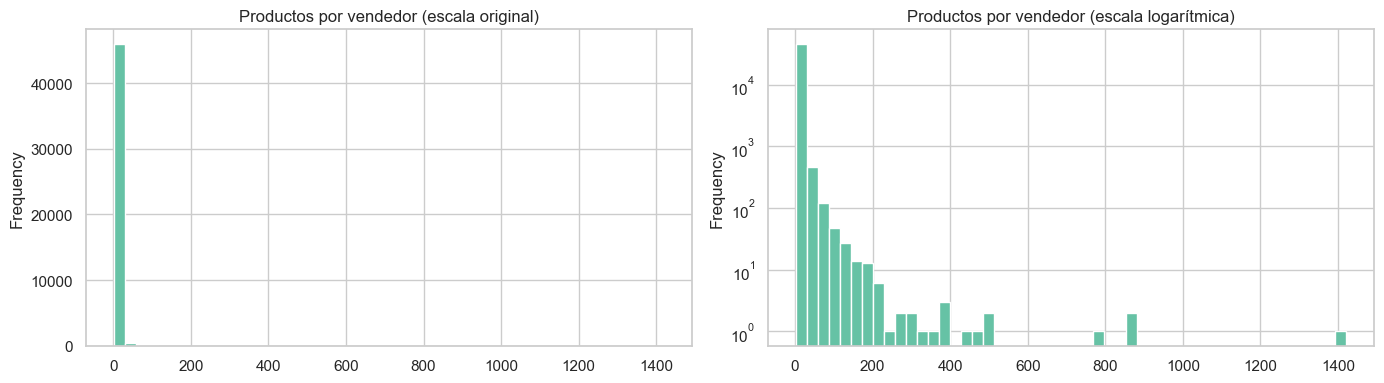

In [23]:
productos_por_seller = df.groupby('seller_nickname').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
productos_por_seller.plot(kind="hist", bins=50, ax=axes[0], title="Productos por vendedor (escala original)")
productos_por_seller.apply(lambda x: x + 1).plot(
    kind="hist", bins=50, ax=axes[1], title="Productos por vendedor (escala logarítmica)", logy=True
)
plt.tight_layout()

## 5. Distribución de precios

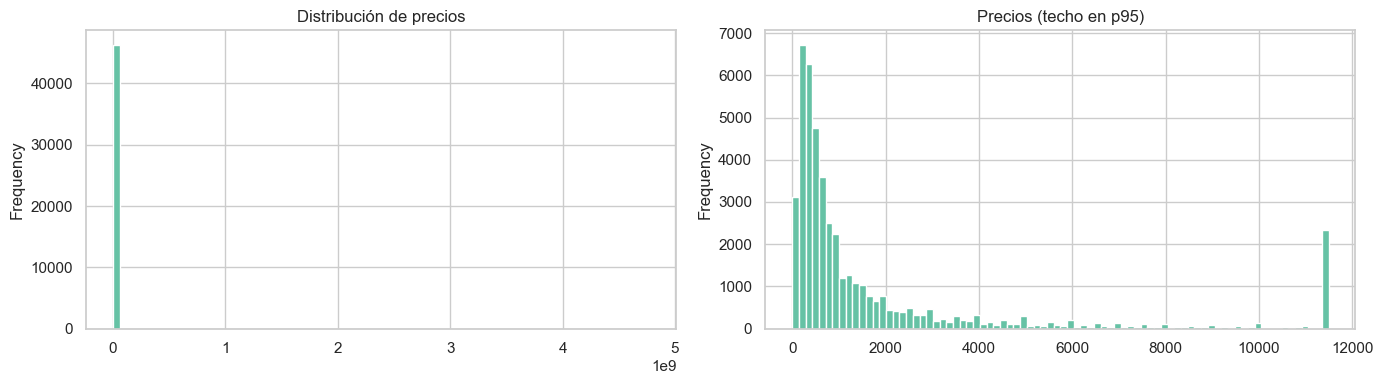

In [24]:
df_price = (df.groupby('seller_nickname').agg(price = ('price', 'mean'),
                                           regular_price=('regular_price', 'mean')).reset_index())
price_var = ['price', 'regular_price']
#Variable price
if price_var:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df_price[price_var[0]].dropna().plot(kind="hist", bins=80, ax=axes[0], title="Distribución de precios")
    df_price[price_var[0]].dropna().clip(upper=df_price[price_var[0]].quantile(0.95)).plot(
        kind="hist", bins=80, ax=axes[1], title="Precios (techo en p95)"
    )
    plt.tight_layout()

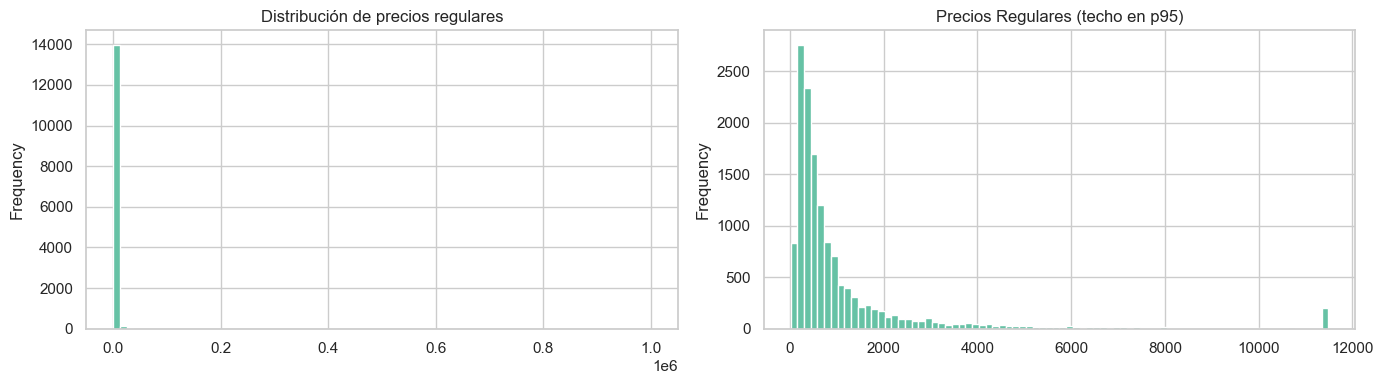

In [25]:
#Variable regular_price
if price_var:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df_price[price_var[1]].dropna().plot(kind="hist", bins=80, ax=axes[0], title="Distribución de precios regulares")
    df_price[price_var[1]].dropna().clip(upper=df_price[price_var[0]].quantile(0.95)).plot(
        kind="hist", bins=80, ax=axes[1], title="Precios Regulares (techo en p95)"
    )
    plt.tight_layout()

## 6. Matriz de correlación

In [26]:
df.columns

Index(['tim_day', 'seller_nickname', 'titulo', 'seller_reputation', 'stock',
       'logistic_type', 'condition', 'is_refurbished', 'price',
       'regular_price', 'categoria', 'url', 'category_id', 'category_name'],
      dtype='str')

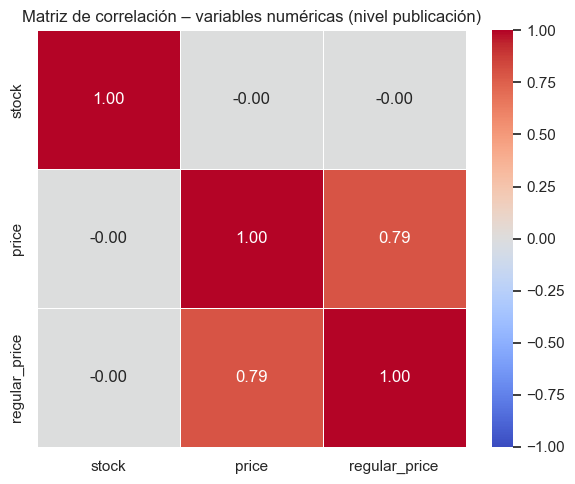

In [27]:
# Correlación a nivel seller entre stock total, precio y precio regular
df_num = df[['seller_nickname', 'stock', 'price', 'regular_price']]
df_cor = (df_num.groupby('seller_nickname').agg(stock = ('stock', 'sum'),
                                           price = ('price', 'mean'),
                                           regular_price=('regular_price', 'mean'))
                                           .reset_index())
numericas = df_cor.select_dtypes(include='number')
corr = numericas.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlación – variables numéricas (nivel publicación)")
plt.tight_layout()

## 7. Persistencia de artefactos

In [28]:
import joblib
from pathlib import Path
select_cols= ['seller_nickname', 'titulo', 'seller_reputation', 'stock',
            'logistic_type', 'condition', 'is_refurbished', 'price',
            'regular_price', 'category_name']
df_save = df[select_cols]
Path("data/interim").mkdir(parents=True, exist_ok=True)

df_save.to_csv("data/interim/sellers_data_clean_var.csv", header=True, index=False)


print("Artefactos guardados.")

Artefactos guardados.


## 8. Hallazgos principales

El dataset corresponde a un snapshot único del **1 de agosto de 2024**, con **185.250 publicaciones** de **46.586 vendedores** distribuidas en **54 categorías**. No se detectaron registros duplicados.

**Calidad de datos**

- Los nulos dentro del dataset no son predominantes: `seller_reputation` (~1,3%) y `price` (~0,8%) son manejables. La excepción es `regular_price` con un 73% de nulos, lo que indica que solo el 27% de las publicaciones tiene un precio de lista diferente al precio de venta, es decir, tienen algún descuento activo.
- `price` presenta valores extremos (máximo $4.772.354.000) que deben tratarse como outliers antes del modelado.
- `stock` también muestra alta dispersión (mediana 8 vs. media 307), con valores de hasta 99.999.

**Distribución de precios y correlaciones**

Se analiza a nivel de seller la distribución y correlación de el total del stock y los precios promedios y precios regulares promedio por seller.

- **Distribución de precios**
    - `price` presenta sesgo extremo a la derecha: la mediana ($663,18) y la media ($135.279) están muy separadas, lo que indica la presencia de valores atípicos de alto impacto. El gráfico sin techo concentra visualmente todo cerca de cero, por lo que el corte en p95 es necesario para observar la distribución real.
    - `regular_price` muestra un máximo de $999.999, valor redondo que probablemente aún no esta definido, por lo que para esta variable en la preparacion de los datos se le dara algún tipo de definición final. 
    - Ambas variables requerirán manejo de atípicos y transformación antes del modelado.

- **Correlaciones**

    - Se observa que no hay correlación entre `stock` y `price`, se interpreta como que sellers con precios altos promedio tienden a manejar menor volumen de unidades, pero la relación no deberá ser necesariamente lineal.
    - La correlación entre `price` y `regular_price` se observa positiva y moderada-alta para las filas donde ambas tienen información, ya que `regular_price` es el precio base del que deriva `price` con descuento.

**Variables categóricas**

- `seller_reputation` está dominada por los niveles más altos: Platinum y Gold concentran el 56% de las publicaciones, lo que refleja que el dataset está sesgado hacia vendedores consolidados.
- `logistic_type` muestra que el 63% de las publicaciones opera bajo Cross Docking (XD), modalidad estándar de Mercado Envíos.
- El 91,6% de las publicaciones corresponde a productos nuevos (`condition = new`).
- `is_refurbished` es casi constante (99,6% False), por lo que aportará muy poco poder discriminatorio.

**Decisiones sobre variables**

- `tim_day`: valor único constante → se elimina del análisis.
- `categoria` y `category_id`: contienen la misma información que `category_name` en inglés → se conserva solo `category_name`.
- `url`: se evaluó webscraping para enriquecer el dataset, pero los sitios no son accesibles → se descarta.